## Imports and Constants ##

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as sc
from scipy.interpolate import interp1d
from scipy import optimize
from scipy.optimize import fsolve

In [21]:
conv_flux = 1e10 # convert W/cm^2/micron to W/m^2/meters
m2mm = 1e3 # convert from m to millimeters
m2um = 1e6 # convert from m to micrometers
m2nm = 1e9 # convert from m to nanometers
mol2umol = 1e6 # convert from micromoles to moles
mW2W = 1e-3 # convert from milliwatts to watts
y2s = 86400*365.25 # convert from years to seconds

## Calculate Sublimation Rates (Figure 4) ##

Saturation pressure at -25°C (248.15 K): 63.283585324181374 Pa
Saturation pressure at 0°C (273.15 K): 611.1535914292243 Pa


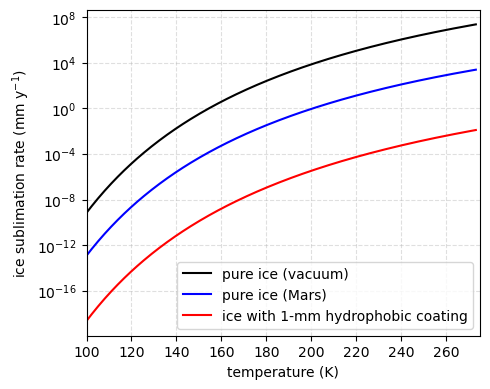

In [26]:
mH2O = sc.u*18.02 # mass of one H2O molecule [kg]
RH2O = sc.R/((mH2O/sc.u)/1e3) # H2O specific gas constant [J kg^-1 K^-1]
rho_H2O_ice = 920.0 # density ice [kg m^-3]
barrer2SI = 3.35e-16 # permeability [mol-1 s-1 Pa-1]; defn. from Baker p. 55 Table 2.2
perm = 100.0*barrer2SI # barrier material permeability [mol-1 s-1 Pa-1]

CD = 3.0e-3 # typical drag coefficient []
U_Mars = 5.0 # Typical Mars wind speed [m s^-1]

## define saturation vapor pressure function for H2O
# Murphy & Koop (2005) equation (7); hexagonal ice
psat_fun = lambda T: np.exp(9.550426 - 5723.265/T + 3.53068*np.log(T) - 0.00728332*T)

print(f"Saturation pressure at -25°C (248.15 K): {psat_fun(248.15)} Pa")
print(f"Saturation pressure at 0°C (273.15 K): {psat_fun(273.15)} Pa")

# Hertz-Knudsen equation
S_pure_ice = lambda T: psat_fun(T)*np.sqrt(mH2O/(2*np.pi*sc.Boltzmann*T))
S_Mars = lambda T: psat_fun(T)*CD*U_Mars/(RH2O*T) # Wordsworth et al. 2015 eqn. (2)
S_barrier = lambda T, t: (mH2O*sc.N_A)*perm*psat_fun(T)/t # Wordsworth et al. 2025 eqn. (5)

T_a = np.linspace(100,273.15,300)

fig, ax = plt.subplots(figsize=(5, 4))

ax.semilogy(T_a,S_pure_ice(T_a)*y2s*m2mm/rho_H2O_ice,color='k',label='pure ice (vacuum)')
ax.semilogy(T_a,S_Mars(T_a)*y2s*m2mm/rho_H2O_ice,color='b',label='pure ice (Mars)')
ax.semilogy(T_a,S_barrier(T_a,1.0e-3)*y2s*m2mm/rho_H2O_ice,color='r',label='ice with 1-mm hydrophobic coating')
ax.set_xlabel('temperature (K)')
ax.set_ylabel('ice sublimation rate (mm y$^{-1}$)')
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend()
ax.set_xlim([100,275])

plt.tight_layout()
plt.show()

# Comparison with industrial data
# https://www.teflon.com/en/-/media/files/teflon/teflon-fep-film-properties-bulletin.pdf?rev=b1a694899129486aa7a3be92abc4d3b7
# 7 g/m2/d --> 8.1e-8 kg/m2/s
# t = 0.025/1e3
# psat is ~3.1 kPa @ 25 C (M-K equation overestimates as it's for ice)
#perm = (8.1e-8/3.1e3)*(0.025/1e3)/(mH2O*sc.N_A)
#print(perm/barrer2SI)
# Teflon FEP is about 100 barrer